# Excersize 1: Markov chain

Write a code to analyze a discrete-time Markov Chain with 5 states (S = (0,1,2,3,4)) using 2 methods.

**Method 1**: Stochastic Simulation

Simulate the chain for large $n$ steps by randomly picking the next state based on the transition probabilities.

Tasks:
*	Plot a frequence of the state occurrences.
*	Calculate the **theoretical steady-state probability** and compare the simulated result with the theoretical value.
*	Determine the **final mean observable** and compare the simulated result with the theoretical value.

**Method 2**: Matrix Iteration

Use the formula
$P_{t+1} = P_t \times T$ or $P_{t+1} = T^T \times P_t$ where $P_{t}$ is the probability distribution vector at the step t. 

*	Compare the resulting distribution and mean observable with the results from Method 1.
*	Why is the final distribution uniform ?
The transition probabilities are defined as:

$T(s_i \rightarrow s_j) = 1/3$ if $j=i\pm 1$ or $j =i$. 


In [40]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [41]:
# states
S = [0, 1, 2, 3, 4]

# transition matrix
T = np.array([
    [1/3, 1/3, 0  , 0  , 1/3],
    [1/3, 1/3, 1/3, 0  , 0  ],
    [0  , 1/3, 1/3, 1/3, 0  ],
    [0  , 0  , 1/3, 1/3, 1/3],
    [1/3, 0  , 0  , 1/3, 1/3]
])

# steps
N = 1_000_000

<h3> 1.1: Stochastic Simulation

In [42]:
def markov_chain_stochastic(S, T, N):
    # set initial state
    current = random.choice(S)
    # create a dictionary to count the occurrences of each state
    occurrences = {state: 0 for state in S}

    # perform N steps of the simulation
    for _ in range(N):
        # update the occurrences of the current state
        occurrences[current] += 1
        # generate a random number between 0 and 1
        rnd = random.uniform(0, 1)
        c = 0
        # iterate through the probabilities of current state (check if rnd is in range: [c, c + p))
        for idx, p in enumerate(T[current]):
            if rnd < c + p:
                current = idx
                break
            c += p

    return occurrences


print(stochastic_results := markov_chain_stochastic(S, T, N))

{0: 199417, 1: 199677, 2: 199856, 3: 201020, 4: 200030}


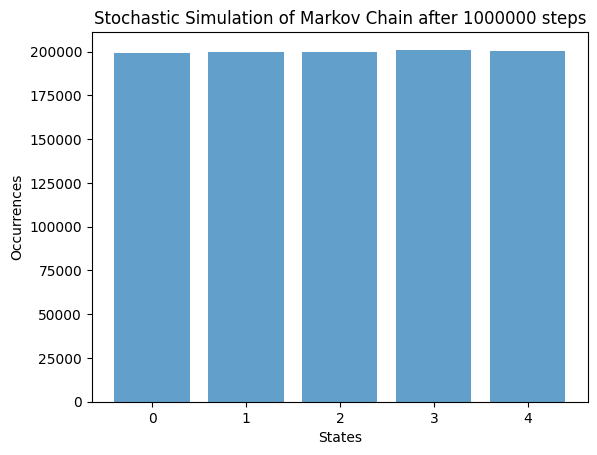

Simulated probabilities: {0: 0.199417, 1: 0.199677, 2: 0.199856, 3: 0.20102, 4: 0.20003}
Theoretical probabilities: {0: 0.2, 1: 0.2, 2: 0.2, 3: 0.2, 4: 0.2}


Simulated mean: 2.002569
Theoretical mean: 2.0


In [43]:
# Plot of frequency of occurrences of each state
plt.bar(x=S, height=list(stochastic_results.values()), alpha=0.7)
plt.xlabel('States')
plt.ylabel('Occurrences')
plt.title(f'Stochastic Simulation of Markov Chain after {N} steps')
plt.show()

# Probability distribution of states
stochastic_prob = {state: count / N for state, count in stochastic_results.items()}
theoretical_prob = {state: 1 / len(S) for state in S}
print("Simulated probabilities:", stochastic_prob)
print("Theoretical probabilities:", theoretical_prob)

print('\n')

# Mean of the observable
stochastic_mean = sum(state * count for state, count in stochastic_results.items()) / N
theoretical_mean = sum(state * prob for state, prob in theoretical_prob.items())
print("Simulated mean:", stochastic_mean)
print("Theoretical mean:", theoretical_mean)

<h3> 1.2: Matrix Iteration

In [44]:
def markov_chain_matrix_iteration(S, T, N):
    prob_vector = np.zeros(len(S))
    # set initial state
    prob_vector[random.choice(S)] = 1

    for _ in range(N):
        # update the probability vector
        prob_vector = prob_vector @ T

    return prob_vector


print(matrix_results := markov_chain_matrix_iteration(S, T, N))

[0.2 0.2 0.2 0.2 0.2]


In [45]:
# Comparison of propability distribution of method 1 & 2
matrix_prob = {state: float(matrix_results[state]) for state in S}
print("Stochastic probabilities:", stochastic_prob)
print("Matrix probabilities:", matrix_prob)

print('\n')

# Comparison of mean of method 1 & 2
matrix_mean = sum(state * prob for state, prob in enumerate(matrix_results))
print("Mean from stochastic simulation:", stochastic_mean)
print("Mean from matrix iteration:", matrix_mean)


Stochastic probabilities: {0: 0.199417, 1: 0.199677, 2: 0.199856, 3: 0.20102, 4: 0.20003}
Matrix probabilities: {0: 0.1999999999999993, 1: 0.1999999999999993, 2: 0.1999999999999993, 3: 0.1999999999999993, 4: 0.1999999999999993}


Mean from stochastic simulation: 2.002569
Mean from matrix iteration: 1.999999999999993


Final probability distribution is uniform, because the probability of entering a state, defined by the transition matrix, is equal to the probability of leaving. Also, all states are accessible in finite amount of steps.

## Exercise 2: Generate the desired distribution
Use 2 methods: MCMC and the transition matrix
1. Choose desired discrete probability distribution $P$
2. Compute acceptance matrix $$A(i,j) = min(1,\dfrac{P(j)}{P(i)})$$

**Method 1**: Stochastic simulation

3. Choose an initial random state $s_i$
3. Yield a proposed state $s_j$ with probability $p$.
4. Compare $p$ and $A(i \rightarrow j)$:
+ $p<= A(i \rightarrow j)$ : accept $s_j$
+ $p > A(i \rightarrow j)$ : reject, keep same state $s_i$
5. Repeat this procedure and compute equilibrium probability $P^{eq}$.

**Method 2**: Transition matrix

3. Compute transition matrix and use matrix iteration $$T(i,j) = g(i,j) A(i,j) , i \neq j$$
$$T(i,j) = g(i,j) A(i,j) + \sum_{k \neq i} g(i,k)(1-A(i,k)) , i = j$$
where we choose $g$ is uniform distribution, i.e $g(i \rightarrow j) = 1/N$ for all $i,j$. 

Repeat all the tasks of exercise 2 for the desired continuous distribution.

In [46]:
# states
S = [0, 1, 2, 3, 4]

# discrete probability distribution
P = [.1, .2, .4, .2, .1]

# steps
N = 1_000_000

<h3> 2.1: Stochastic Simulation:

In [47]:
def get_distribution_stochastic(S, P, N):
    # set initial state
    current = random.choice(S)
    # create a dictionary to count the occurrences of each state
    occurrences = {state: 0 for state in S}

    # perform N steps of the simulation
    for _ in range(N):
        # update the occurrences of the current state
        occurrences[current] += 1

        # generate a proposed state
        proposed = random.choice(S)

        # calculate acceptance probability
        acceptance = min(1.0, P[proposed] / P[current])

        # accept or reject the proposed state (if rejected -> stay in the current state)
        if random.uniform(0, 1) < acceptance:
            current = proposed

    return occurrences


print(distr_stochastic := get_distribution_stochastic(S, P, N))

{0: 99959, 1: 200420, 2: 399577, 3: 200030, 4: 100014}


In [48]:
print("Desired vs simulated probabilities:")
for idx, val in enumerate(distr_stochastic.values()):
    print(f"d: {P[idx]}, s: {val / N}")

Desired vs simulated probabilities:
d: 0.1, s: 0.099959
d: 0.2, s: 0.20042
d: 0.4, s: 0.399577
d: 0.2, s: 0.20003
d: 0.1, s: 0.100014


<h3> 2.2: Matrix Iteration:

In [49]:
def get_distribution_matrix(S, P, N):
    # initialization of transition matrix
    T = np.zeros((len(S), len(S)))
    # uniform proposal distribution
    g = 1.0 / len(S)

    # fill the transition matrix (all combinations of current and proposed states)
    for current in range(len(S)):
        for proposed in range(len(S)):
            # calculate acceptance probability
            acceptance = min(1.0, P[proposed] / P[current])

            if current != proposed:
                # probability of changing a state from i to j (formula: 3a)
                T[current][proposed] = g * acceptance
            else:
                # calculate the sum of probabilities of rejecting the proposed states
                rejection_sum = 0
                for state in range(len(S)):
                    if state != current:
                        rejection_sum += g * (1 - min(1.0, P[state] / P[current]))

                # probability of staying in the same state (formula: 3b)
                T[current][current] = g * acceptance + rejection_sum

    return T


print(distr_matrix := get_distribution_matrix(S, P, N))

[[0.2  0.2  0.2  0.2  0.2 ]
 [0.1  0.4  0.2  0.2  0.1 ]
 [0.05 0.1  0.7  0.1  0.05]
 [0.1  0.2  0.2  0.4  0.1 ]
 [0.2  0.2  0.2  0.2  0.2 ]]
